# Sample time-domain pSEOBNRv5HM ringdown-deviation plot

This notebook generates a simple visual comparison between:

- GR time-domain `SEOBNRv5HM`
- modified-ringdown time-domain `SEOBNRv5HM` with `dOmega = dTau = 0.1`

The plot is intentionally minimal: it focuses on the dominant `(2,2)` mode so it is easy to use in a thesis slide.

The deviation is applied through pySEOBNR-style dictionaries:

```python
domega_dict = {"2,2": 0.1, ...}
dtau_dict   = {"2,2": 0.1, ...}
```

A positive `dOmega` shifts the ringdown oscillation frequency, while a positive `dTau` changes the damping time. For this illustrative plot, the waveform is generated only for a short observation time before merger to keep it fast.


In [1]:
# If you run this in Jupyter:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
from typing import get_args

from pyseobnr.generate_waveform import GenerateWaveform, SupportedApproximants

# Solar mass in seconds. This avoids needing lisabeta just for MTSUN_SI.
MTSUN_SI = 4.925490947e-6

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": ":",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})


## Physical parameters

These are the same kind of M1e6 example values used in your dOmega/dTau notebooks. The plot uses only the `(2,2)` mode by default because that is the clearest way to show the ringdown modification visually.


In [2]:
# -------------------------------------------------------------------------
# Physical parameters
# -------------------------------------------------------------------------
params_base = {
    "M": 1e6,                         # total mass in solar masses
    "q": 4.0,                         # m1 / m2
    "chi1": 0.5,
    "chi2": 0.5,
    "dist": 6791.810623950696,        # Mpc, roughly z = 1 in your setup
    "inc": np.pi / 3,
    "phi": 0.7,
}

# Plot only h_22 by default.
# You can add other modes here, but the figure becomes less clean.
modes = [(2, 2)]

# Ringdown deviation applied to the (2,2) mode.
d_omega = 0.1
d_tau = 0.1
deviation_modes = [(2, 2)]

print("Supported pySEOBNR approximants:", get_args(SupportedApproximants))


Supported pySEOBNR approximants: ('SEOBNRv5HM', 'SEOBNRv5PHM', 'SEOBNRv5EHM')


## Helper functions

The important part is the `domega_dict` and `dtau_dict` passed into `GenerateWaveform`. For the GR waveform we set them to zero. For the deviated waveform we set `dOmega = dTau = 0.1` for the `(2,2)` mode.


In [3]:
def mode_key_variants(lm):
    l, m = lm
    return [lm, (l, m), f"{l},{m}", f"{l}{m}", f"h{l}{m}"]


def get_mode_from_dict(hlm, lm):
    for key in mode_key_variants(lm):
        if key in hlm:
            return hlm[key]
    raise KeyError(f"Mode {lm} not found. Available keys: {list(hlm.keys())[:20]}")


def make_deviation_dicts(d_omega_value, d_tau_value, modes, deviation_modes):
    domega_dict = {
        f"{l},{m}": (float(d_omega_value) if (l, m) in deviation_modes else 0.0)
        for (l, m) in modes
    }
    dtau_dict = {
        f"{l},{m}": (float(d_tau_value) if (l, m) in deviation_modes else 0.0)
        for (l, m) in modes
    }
    return domega_dict, dtau_dict


def newtonian_f_from_time_before_merger(m1, m2, T_obs):
    """Crude Newtonian estimate of f22_start from a requested duration before merger.

    This is only used to keep the sample waveform short and fast.
    Masses are in solar masses, T_obs is in seconds, output is Hz.
    """
    M = m1 + m2
    nu = (m1 * m2) / M**2
    M_seconds = M * MTSUN_SI
    return ((5.0 / (256.0 * nu)) * (M_seconds / T_obs))**(3.0 / 8.0) / (np.pi * M_seconds)


def choose_deltaT(M, maxf=0.2, user_deltaT=None):
    """Safe sampling interval for a sample time-domain pySEOBNR plot."""
    M_seconds = M * MTSUN_SI
    f_rd_est = 0.08 / M_seconds

    delta_from_maxf = 1.0 / (4.0 * maxf)
    delta_from_ringdown = 1.0 / (8.0 * f_rd_est)
    auto_deltaT = min(delta_from_maxf, delta_from_ringdown)

    if user_deltaT is None:
        return auto_deltaT, f_rd_est

    return min(float(user_deltaT), auto_deltaT), f_rd_est


def build_pyseobnr_params(params, modes, domega_dict=None, dtau_dict=None,
                         T_obs=6 * 3600, maxf=0.2, deltaT=None):
    """Build the dictionary passed to pySEOBNR GenerateWaveform."""
    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    f22_start = newtonian_f_from_time_before_merger(m1, m2, T_obs)
    dt, f_rd_est = choose_deltaT(M, maxf=maxf, user_deltaT=deltaT)

    params_pseob = {
        "mass1": m1,
        "mass2": m2,
        "spin1x": 0.0,
        "spin1y": 0.0,
        "spin1z": float(params.get("chi1", 0.0)),
        "spin2x": 0.0,
        "spin2y": 0.0,
        "spin2z": float(params.get("chi2", 0.0)),
        "distance": float(params.get("dist", 1.0)),
        "inclination": float(params.get("inc", 0.0)),
        "phi_ref": float(params.get("phi", 0.0)),
        "f22_start": f22_start,
        "f_ref": f22_start,
        "f_max": float(maxf),
        "deltaT": dt,
        "approximant": "SEOBNRv5HM",
        "mode_array": modes,
    }

    if domega_dict is not None:
        params_pseob["domega_dict"] = domega_dict
    if dtau_dict is not None:
        params_pseob["dtau_dict"] = dtau_dict

    info = {
        "m1": m1,
        "m2": m2,
        "f22_start": f22_start,
        "deltaT": dt,
        "f_rd_est": f_rd_est,
        "T_obs": T_obs,
    }

    return params_pseob, info


def generate_td_modes(params_pseob, modes):
    times, hlm_raw = GenerateWaveform(params_pseob).generate_td_modes()
    times = np.asarray(times, dtype=float)

    hlm = {}
    for lm in modes:
        hlm[lm] = np.asarray(get_mode_from_dict(hlm_raw, lm), dtype=complex)

    return times, hlm


## Generate GR and modified-ringdown waveforms

For speed, this sample starts roughly 6 hours before merger. For a longer inspiral, increase `T_obs`, for example `T_obs = 3 * 86400`.


In [4]:
# -------------------------------------------------------------------------
# Generation controls
# -------------------------------------------------------------------------
T_obs = 6 * 3600      # 6 hours before merger, chosen for a fast sample plot
maxf = 0.2
deltaT = None         # keep None unless you want to force a particular sampling

# GR: no ringdown deviations
zero_domega_dict, zero_dtau_dict = make_deviation_dicts(
    0.0, 0.0, modes=modes, deviation_modes=deviation_modes
)

# Deviated: dOmega = dTau = 0.1 in the chosen mode
domega_dict, dtau_dict = make_deviation_dicts(
    d_omega, d_tau, modes=modes, deviation_modes=deviation_modes
)

params_gr, info_gr = build_pyseobnr_params(
    params_base,
    modes=modes,
    domega_dict=zero_domega_dict,
    dtau_dict=zero_dtau_dict,
    T_obs=T_obs,
    maxf=maxf,
    deltaT=deltaT,
)

params_dev, info_dev = build_pyseobnr_params(
    params_base,
    modes=modes,
    domega_dict=domega_dict,
    dtau_dict=dtau_dict,
    T_obs=T_obs,
    maxf=maxf,
    deltaT=deltaT,
)

print("GR generation info:")
for k, v in info_gr.items():
    print(f"  {k}: {v}")

print("\nDeviation dictionaries:")
print("  domega_dict =", domega_dict)
print("  dtau_dict   =", dtau_dict)

print("\nGenerating GR waveform...")
t_gr, hlm_gr = generate_td_modes(params_gr, modes)

print("Generating modified-ringdown waveform...")
t_dev, hlm_dev = generate_td_modes(params_dev, modes)

print("\nGenerated samples:")
print("  GR :", len(t_gr), "samples")
print("  DEV:", len(t_dev), "samples")


GR generation info:
  m1: 800000.0
  m2: 200000.0
  f22_start: 0.001265108543251707
  deltaT: 1.25
  f_rd_est: 0.016242035740361295
  T_obs: 21600

Deviation dictionaries:
  domega_dict = {'2,2': 0.1}
  dtau_dict   = {'2,2': 0.1}

Generating GR waveform...
Generating modified-ringdown waveform...

Generated samples:
  GR : 18658 samples
  DEV: 18800 samples


## Prepare the `(2,2)` mode for plotting

The time axis is shifted so that the peak of `|h_22|` occurs at `t = 0`. I also normalize by the peak amplitude, because this makes the figure easier to read on a slide.


In [5]:
lm_plot = (2, 2)

h_gr = hlm_gr[lm_plot]
h_dev = hlm_dev[lm_plot]

# Use each waveform's own peak as t = 0.
t0_gr = t_gr[np.argmax(np.abs(h_gr))]
t0_dev = t_dev[np.argmax(np.abs(h_dev))]

t_gr_rel = t_gr - t0_gr
t_dev_rel = t_dev - t0_dev

# Normalize for a clean visual comparison.
h_gr_norm = h_gr / np.max(np.abs(h_gr))
h_dev_norm = h_dev / np.max(np.abs(h_dev))

print(f"GR peak time:  {t0_gr:.3f} s")
print(f"DEV peak time: {t0_dev:.3f} s")


GR peak time:  0.304 s
DEV peak time: -0.021 s


## Plot 1: real part near merger and ringdown

This is usually the best figure for a slide, because it shows the actual oscillatory waveform.


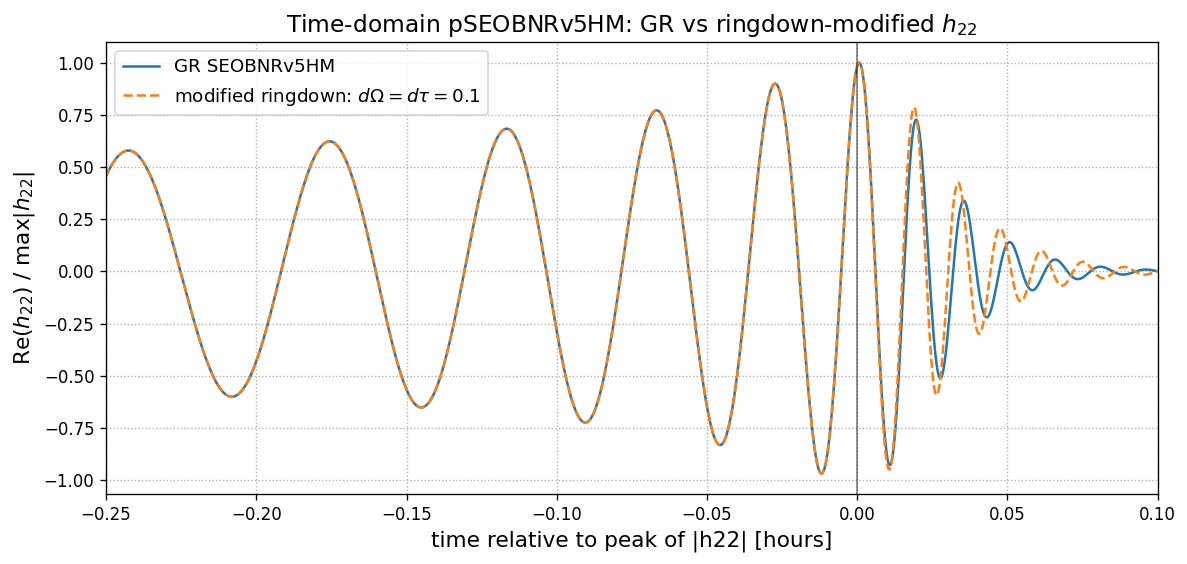

In [6]:
# Plot window around merger/ringdown.
# Adjust these if you want more inspiral or more late ringdown.
t_min = -2500
t_max = 2000

mask_gr = (t_gr_rel >= t_min) & (t_gr_rel <= t_max)
mask_dev = (t_dev_rel >= t_min) & (t_dev_rel <= t_max)

plt.figure(figsize=(10, 4.8))
plt.plot(t_gr_rel[mask_gr] / 3600, np.real(h_gr_norm[mask_gr]),
         label="GR SEOBNRv5HM")
plt.plot(t_dev_rel[mask_dev] / 3600, np.real(h_dev_norm[mask_dev]),
         linestyle="--",
         label=r"modified ringdown: $d\Omega=d\tau=0.1$")

plt.axvline(0.0, color="k", linewidth=1.0, alpha=0.5)
plt.xlabel("time relative to peak of |h22| [hours]")
plt.ylabel(r"Re$(h_{22})$ / max$|h_{22}|$")
plt.xlim(-0.25, 0.1)
plt.title(r"Time-domain pSEOBNRv5HM: GR vs ringdown-modified $h_{22}$")
plt.legend()
plt.tight_layout()
plt.savefig("pseobnrv5hm_domega_dtau_0p1_real_h22.png", dpi=250)
plt.show()


## Plot 2: ringdown envelope

This plot makes the damping-time modification easier to see. A positive `dTau` should alter the post-peak decay of the ringdown envelope.


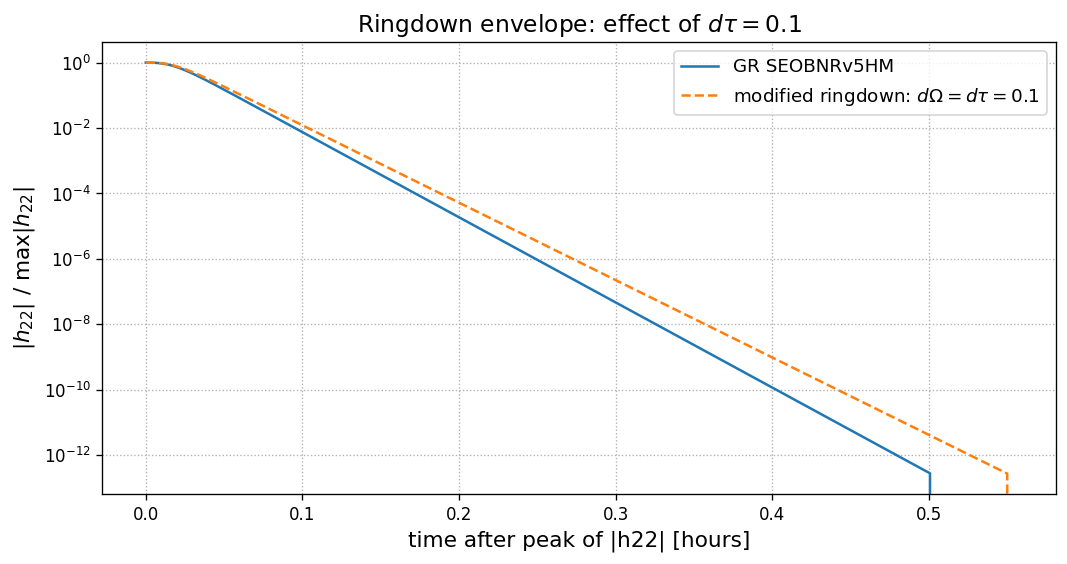

In [7]:
t_min_rd = 0
t_max_rd = 5000

mask_gr_rd = (t_gr_rel >= t_min_rd) & (t_gr_rel <= t_max_rd)
mask_dev_rd = (t_dev_rel >= t_min_rd) & (t_dev_rel <= t_max_rd)

plt.figure(figsize=(9, 4.8))
plt.semilogy(t_gr_rel[mask_gr_rd] / 3600, np.abs(h_gr_norm[mask_gr_rd]),
             label="GR SEOBNRv5HM")
plt.semilogy(t_dev_rel[mask_dev_rd] / 3600, np.abs(h_dev_norm[mask_dev_rd]),
             linestyle="--",
             label=r"modified ringdown: $d\Omega=d\tau=0.1$")

plt.xlabel("time after peak of |h22| [hours]")
plt.ylabel(r"$|h_{22}|$ / max$|h_{22}|$")
plt.title(r"Ringdown envelope: effect of $d\tau=0.1$")
plt.legend()
plt.tight_layout()
plt.savefig("pseobnrv5hm_domega_dtau_0p1_envelope_h22.png", dpi=250)
plt.show()


## Optional: instantaneous phase after the peak

This is useful if you want to emphasize that `dOmega` modifies the ringdown frequency. The phase evolution should separate after the peak.


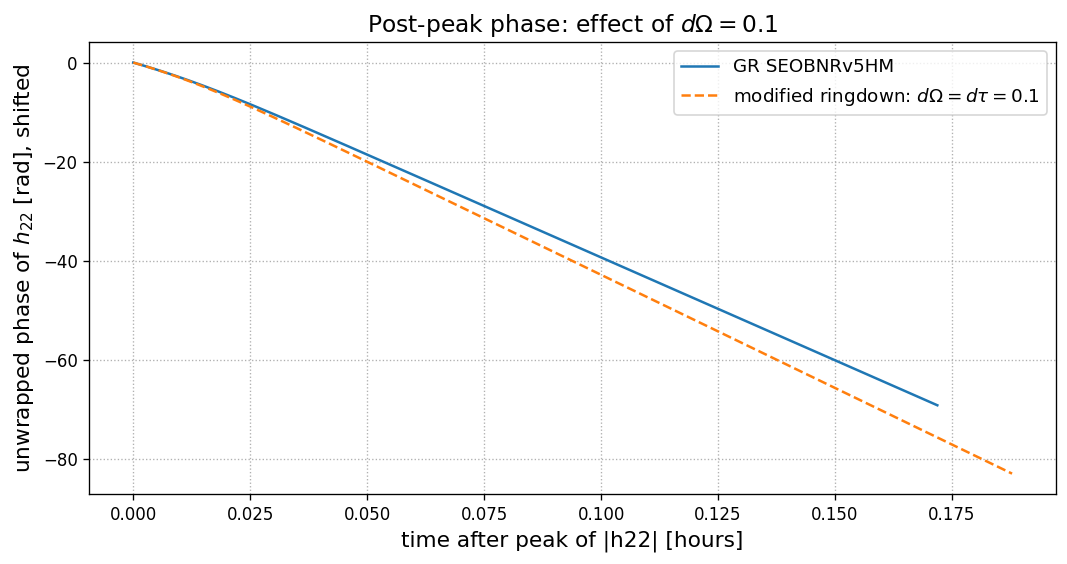

In [8]:
# Unwrap phase only where the amplitude is not too tiny.
mask_gr_phase = (t_gr_rel >= 0) & (t_gr_rel <= 3000) & (np.abs(h_gr_norm) > 1e-4)
mask_dev_phase = (t_dev_rel >= 0) & (t_dev_rel <= 3000) & (np.abs(h_dev_norm) > 1e-4)

phase_gr = np.unwrap(np.angle(h_gr_norm[mask_gr_phase]))
phase_dev = np.unwrap(np.angle(h_dev_norm[mask_dev_phase]))

# Shift phases to start from zero for visual comparison.
phase_gr -= phase_gr[0]
phase_dev -= phase_dev[0]

plt.figure(figsize=(9, 4.8))
plt.plot(t_gr_rel[mask_gr_phase] / 3600, phase_gr, label="GR SEOBNRv5HM")
plt.plot(t_dev_rel[mask_dev_phase] / 3600, phase_dev, linestyle="--",
         label=r"modified ringdown: $d\Omega=d\tau=0.1$")

plt.xlabel("time after peak of |h22| [hours]")
plt.ylabel(r"unwrapped phase of $h_{22}$ [rad], shifted")
plt.title(r"Post-peak phase: effect of $d\Omega=0.1$")
plt.legend()
plt.tight_layout()
plt.savefig("pseobnrv5hm_domega_dtau_0p1_phase_h22.png", dpi=250)
plt.show()


## Slide wording you can use

For this figure, you can say:

> We generate a time-domain pSEOBNRv5HM waveform and modify the ringdown by changing the quasi-normal-mode frequency and damping time. Here I show a toy case with `dOmega = dTau = 0.1` in the dominant `(2,2)` mode. The inspiral is almost unchanged, while the post-merger/ringdown oscillation and decay are visibly shifted.


Generating GR waveform...
Generating waveform with dOmega = dTau = -0.100
Generating waveform with dOmega = dTau = -0.098
Generating waveform with dOmega = dTau = -0.096
Generating waveform with dOmega = dTau = -0.094
Generating waveform with dOmega = dTau = -0.092
Generating waveform with dOmega = dTau = -0.090
Generating waveform with dOmega = dTau = -0.088
Generating waveform with dOmega = dTau = -0.086
Generating waveform with dOmega = dTau = -0.084
Generating waveform with dOmega = dTau = -0.082
Generating waveform with dOmega = dTau = -0.080
Generating waveform with dOmega = dTau = -0.078
Generating waveform with dOmega = dTau = -0.076
Generating waveform with dOmega = dTau = -0.074
Generating waveform with dOmega = dTau = -0.072
Generating waveform with dOmega = dTau = -0.070
Generating waveform with dOmega = dTau = -0.068
Generating waveform with dOmega = dTau = -0.066
Generating waveform with dOmega = dTau = -0.064
Generating waveform with dOmega = dTau = -0.062
Generating wav

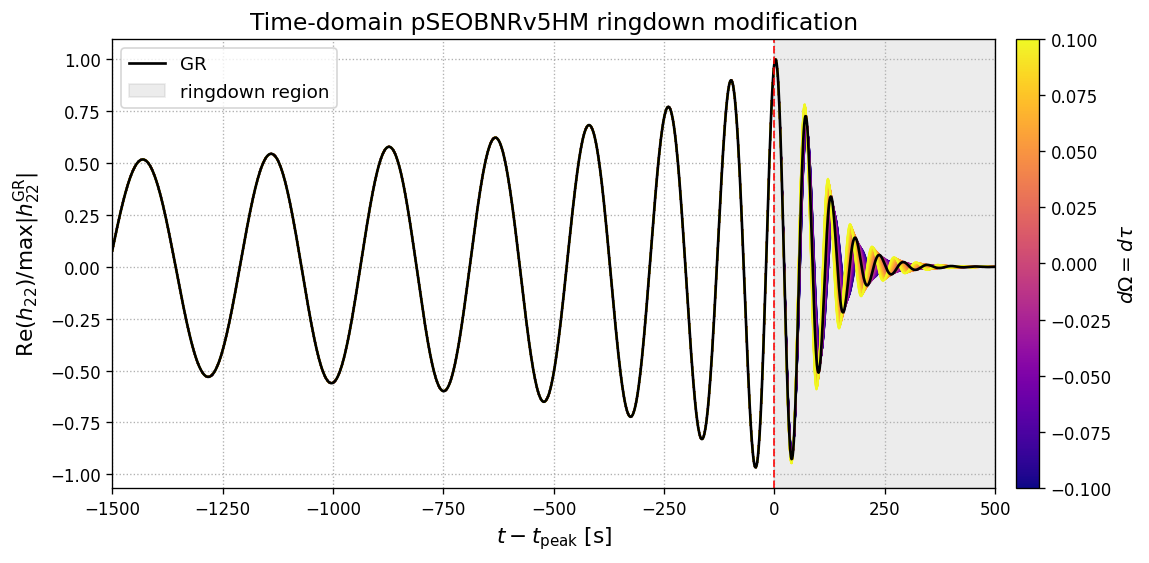

In [20]:
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# -------------------------------------------------------------------------
# Figure-1-style plot: GR black + colored range of ringdown deviations
# -------------------------------------------------------------------------

lm_plot = (2, 2)

dev_values = np.linspace(-0.1, 0.1, 100)

zero_domega_dict, zero_dtau_dict = make_deviation_dicts(
    0.0, 0.0, modes=modes, deviation_modes=deviation_modes
)

params_gr, info_gr = build_pyseobnr_params(
    params_base,
    modes=modes,
    domega_dict=zero_domega_dict,
    dtau_dict=zero_dtau_dict,
    T_obs=T_obs,
    maxf=maxf,
    deltaT=deltaT,
)

print("Generating GR waveform...")
t_gr, hlm_gr = generate_td_modes(params_gr, modes)

h_gr = hlm_gr[lm_plot]

t0_gr = t_gr[np.argmax(np.abs(h_gr))]
t_gr_rel = t_gr - t0_gr

h_norm = np.max(np.abs(h_gr))
h_gr_plot = np.real(h_gr) / h_norm

# Plot window in seconds
t_min = -1500
t_max = 500

mask_gr = (t_gr_rel >= t_min) & (t_gr_rel <= t_max)

cmap = cm.plasma
norm = Normalize(vmin=np.min(dev_values), vmax=np.max(dev_values))

fig, ax = plt.subplots(figsize=(10, 4.8))

# Deviated waveforms
for dev in dev_values:
    domega_dict, dtau_dict = make_deviation_dicts(
        dev, dev, modes=modes, deviation_modes=deviation_modes
    )

    params_dev, info_dev = build_pyseobnr_params(
        params_base,
        modes=modes,
        domega_dict=domega_dict,
        dtau_dict=dtau_dict,
        T_obs=T_obs,
        maxf=maxf,
        deltaT=deltaT,
    )

    print(f"Generating waveform with dOmega = dTau = {dev:+.3f}")
    t_dev, hlm_dev = generate_td_modes(params_dev, modes)

    h_dev = hlm_dev[lm_plot]

    t0_dev = t_dev[np.argmax(np.abs(h_dev))]
    t_dev_rel = t_dev - t0_dev

    h_dev_plot = np.real(h_dev) / h_norm

    mask_dev = (t_dev_rel >= t_min) & (t_dev_rel <= t_max)

    ax.plot(
        t_dev_rel[mask_dev],
        h_dev_plot[mask_dev],
        color=cmap(norm(dev)),
        linewidth=1.0,
        alpha=0.9,
    )

# GR waveform on top
ax.plot(
    t_gr_rel[mask_gr],
    h_gr_plot[mask_gr],
    color="black",
    linewidth=1.6,
    label="GR"
)

# Peak/ringdown marker
ax.axvline(0.0, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
#ax.text(40, 0.85, r"peak of $|h_{22}|$", color="red", fontsize=11)

# Optional ringdown shading
ax.axvspan(0.0, t_max, color="grey", alpha=0.15, label="ringdown region")

# Correct colorbar call
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$d\Omega=d\tau$", fontsize=12)

ax.set_xlim(t_min, t_max)
ax.set_xlabel(r"$t-t_{\rm peak}$ [s]")
ax.set_ylabel(r"Re$(h_{22})/\max |h_{22}^{\rm GR}|$")
ax.set_title(r"Time-domain pSEOBNRv5HM ringdown modification")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig("pseobnrv5hm_domega_dtau_range_fig1_style.png", dpi=300)
plt.show()